# 1.1. THỐNG KÊ MÔ TẢ


## 1.1.2. Bài làm mẫu


### Nhiệm vụ 1: Khám phá dữ liệu COVID


In [ ]:
# Nhiệm vụ 1: Khám phá dữ liệu COVID trực tiếp từ Our World in Data
# (phiên bản đơn giản, chỉ dùng các cột hiện có)

import numpy as np
import pandas as pd
from scipy import stats

# 1. Nạp dữ liệu trực tiếp từ Our World in Data
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
covid_data = pd.read_csv(url)

# 2. Giữ lại các cột chính (theo cấu trúc hiện tại)
covid_data = covid_data[['country', 'date', 'total_cases', 'new_cases']]

# 3. Kiểm tra dữ liệu
print("===== THÔNG TIN CƠ BẢN =====")
print(covid_data.head(5))
print(covid_data.dtypes)
print(covid_data.shape)

# 4. Làm sạch dữ liệu
covid_data = covid_data.dropna(subset=['new_cases'])

# 5. Tính toán các chỉ số thống kê mô tả
data_mean = np.mean(covid_data["new_cases"])
data_median = np.median(covid_data["new_cases"])
data_mode = stats.mode(covid_data["new_cases"], keepdims=True)
data_variance = np.var(covid_data["new_cases"])
data_sd = np.std(covid_data["new_cases"])
data_max = np.max(covid_data["new_cases"])
data_min = np.min(covid_data["new_cases"])
data_range = data_max - data_min
data_percentile = np.percentile(covid_data["new_cases"], 60)
q1, q2, q3 = np.percentile(covid_data["new_cases"], [25, 50, 75])
data_IQR = stats.iqr(covid_data["new_cases"])

# 6. In kết quả
print("\n===== THỐNG KÊ MÔ TẢ TOÀN BỘ DỮ LIỆU COVID =====")
print(f"Mean (Trung bình): {data_mean:.2f}")
print(f"Median (Trung vị): {data_median:.2f}")
print(f"Mode (Giá trị thường gặp): {data_mode.mode[0]:.2f}")
print(f"Variance (Phương sai): {data_variance:.2f}")
print(f"Standard Deviation (Độ lệch chuẩn): {data_sd:.2f}")
print(f"Max (Giá trị lớn nhất): {data_max:.2f}")
print(f"Min (Giá trị nhỏ nhất): {data_min:.2f}")
print(f"Range (Khoảng biến thiên): {data_range:.2f}")
print(f"60th Percentile (Phân vị thứ 60): {data_percentile:.2f}")
print(f"Quartiles (Q1, Q2, Q3): {q1:.2f}, {q2:.2f}, {q3:.2f}")
print(f"IQR (Khoảng tứ phân vị): {data_IQR:.2f}")




===== THÔNG TIN CƠ BẢN =====
       country        date  total_cases  new_cases
0  Afghanistan  2020-01-01          NaN        NaN
1  Afghanistan  2020-01-02          NaN        NaN
2  Afghanistan  2020-01-03          NaN        NaN
3  Afghanistan  2020-01-04          0.0        0.0
4  Afghanistan  2020-01-05          0.0        0.0
country         object
date            object
total_cases    float64
new_cases      float64
dtype: object
(535365, 4)

===== THỐNG KÊ MÔ TẢ TOÀN BỘ DỮ LIỆU COVID =====
Mean (Trung bình): 10486.79
Median (Trung vị): 0.00
Mode (Giá trị thường gặp): 0.00
Variance (Phương sai): 13698666650.62
Standard Deviation (Độ lệch chuẩn): 117041.30
Max (Giá trị lớn nhất): 8401906.00
Min (Giá trị nhỏ nhất): 0.00
Range (Khoảng biến thiên): 8401906.00
60th Percentile (Phân vị thứ 60): 0.00
Quartiles (Q1, Q2, Q3): 0.00, 0.00, 61.00
IQR (Khoảng tứ phân vị): 61.00


### Nhiệm vụ 2: Khám phá và xử lý dữ liệu Marketing Campaign


In [ ]:
# 1) Import & nạp dữ liệu vào notebook
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"

marketing_data = pd.read_csv(url, sep=';')
cols = ['ID','Year_Birth','Education','Marital_Status','Income',
        'Kidhome','Teenhome','Dt_Customer','Recency',
        'NumStorePurchases','NumWebVisitsMonth']

# Một số bản dữ liệu có thể khác tên nhẹ; đảm bảo chọn được cột hợp lệ
existing_cols = [c for c in cols if c in marketing_data.columns]
marketing_data = marketing_data[existing_cols]

# 2) Loại bỏ dữ liệu trùng lặp (đúng cú pháp code mẫu)
print("== Head & info trước khi xử lý ==")
print(marketing_data.head())
print(marketing_data.dtypes)
print("Shape:", marketing_data.shape)

# Remove duplicates
marketing_data_duplicate = marketing_data.drop_duplicates()

# Delete row index 1 (nếu tồn tại)
if 1 in marketing_data.index:
    marketing_data = marketing_data.drop(labels=[1], axis=0)

# Delete a single column (Year_Birth) nếu có
if 'Year_Birth' in marketing_data.columns:
    marketing_data = marketing_data.drop(labels=['Year_Birth'], axis=1)

# 3) Thay thế dữ liệu & đổi kiểu dữ liệu (theo code mẫu)
# Replace Teenhome -> has teen / has no teen
if 'Teenhome' in marketing_data.columns:
    marketing_data['Teenhome_replaced'] = marketing_data['Teenhome'].replace(
        [0, 1, 2], ['has no teen', 'has teen', 'has teen']
    )

# Fill NAs in Income
if 'Income' in marketing_data.columns:
    marketing_data['Income'] = marketing_data['Income'].fillna(0)
    # Change dtype float -> int (tạo cột mới)
    marketing_data['Income_changed'] = marketing_data['Income'].astype(int)

# 4) Xử lý dữ liệu thiếu (missing values)
print("\n== Missing values theo cột ==")
print(marketing_data.isnull().sum())

marketing_data_withoutna = marketing_data.dropna(how='any')
print("\n== Shape sau khi dropna(how='any') ==")
print(marketing_data_withoutna.shape)


== Head & info trước khi xử lý ==
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  NumStorePurchases  NumWebVisitsMonth  
0  2012-09-04       58                  4                  7  
1  2014-03-08       38                  2                  5  
2  2013-08-21       26                 10                  4  
3  2014-02-10       26                  4                  6  
4  2014-01-19       94                  6                  5  
ID                     int64
Year_Birth             int64
Education             object
Marital_Status        object
Inc

### 1.1.3. Bài tập thực hành 1
Thực hiện thống kê mô tả trên tập dữ liệu về phân loại chất lượng rượu đỏ.

In [ ]:


import numpy as np
import pandas as pd
from scipy import stats

# 1. Import thư viện & nạp dữ liệu
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

# 2. Khám phá dữ liệu ban đầu
print("===== THÔNG TIN BAN ĐẦU =====")
print(wine_data.head(5))
print(wine_data.info())
print("Kích thước dữ liệu:", wine_data.shape)

# 3. Xử lý dữ liệu (theo đúng cấu trúc lab)
## 3.1. Loại bỏ dữ liệu trùng lặp
wine_data = wine_data.drop_duplicates()
print("\nSau khi loại bỏ trùng lặp:", wine_data.shape)

## 3.2. Kiểm tra giá trị thiếu
print("\nSố lượng giá trị thiếu trong mỗi cột:")
print(wine_data.isnull().sum())

## 3.3. Thay thế hoặc xử lý giá trị thiếu (nếu có)
wine_data = wine_data.fillna(wine_data.mean(numeric_only=True))

## 3.4. Đổi kiểu dữ liệu (cho đồng nhất)
wine_data = wine_data.astype(float)

# 4. Tạo cột thay thế minh họa (giống cấu trúc lab)
wine_data["Quality_Label"] = wine_data["quality"].apply(lambda x: "Good" if x >= 7 else "Normal")

print("\nSau khi thêm cột Quality_Label:")
print(wine_data[["quality", "Quality_Label"]].head())

# 5. Thống kê mô tả tổng quát
print("\n===== THỐNG KÊ MÔ TẢ TỔNG QUÁT =====")
print(wine_data.describe())

# 6. Thống kê mô tả chi tiết cho cột 'alcohol'
col = "alcohol"
values = wine_data[col]

data_mean = np.mean(values)
data_median = np.median(values)
data_mode = stats.mode(values, keepdims=True)
data_variance = np.var(values)
data_sd = np.std(values)
data_max = np.max(values)
data_min = np.min(values)
data_range = data_max - data_min
data_percentile = np.percentile(values, 60)
q1, q2, q3 = np.percentile(values, [25, 50, 75])
data_IQR = stats.iqr(values)

print(f"\n===== THỐNG KÊ MÔ TẢ CHI TIẾT CHO '{col}' =====")
print(f"Mean (Trung bình): {data_mean:.2f}")
print(f"Median (Trung vị): {data_median:.2f}")
print(f"Mode (Giá trị thường gặp): {data_mode.mode[0]:.2f}")
print(f"Variance (Phương sai): {data_variance:.2f}")
print(f"Standard Deviation (Độ lệch chuẩn): {data_sd:.2f}")
print(f"Min (Nhỏ nhất): {data_min:.2f}")
print(f"Max (Lớn nhất): {data_max:.2f}")
print(f"Range (Khoảng biến thiên): {data_range:.2f}")
print(f"60th Percentile (Phân vị 60%): {data_percentile:.2f}")
print(f"Quartiles (Q1, Q2, Q3): {q1:.2f}, {q2:.2f}, {q3:.2f}")
print(f"IQR (Khoảng tứ phân vị): {data_IQR:.2f}")

# 7. Trung bình độ cồn theo nhóm chất lượng
print("\n===== TRUNG BÌNH ĐỘ CỒN THEO NHÓM CHẤT LƯỢNG =====")
print(wine_data.groupby("Quality_Label")["alcohol"].mean())


===== THÔNG TIN BAN ĐẦU =====
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8  

### 1.1.4. Bài tập thực hành 2
Thực hiện thống kê mô tả trên tập dữ liệu về bệnh tiểu đường

In [ ]:

# 1. Import thư viện & nạp dữ liệu
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
        "BMI","DiabetesPedigreeFunction","Age","Outcome"]
diabetes_data = pd.read_csv(url, names=cols)

# 2. Khám phá dữ liệu ban đầu
print("===== THÔNG TIN BAN ĐẦU =====")
print(diabetes_data.head(5))
print(diabetes_data.info())
print("Kích thước dữ liệu:", diabetes_data.shape)

# 3. Xử lý dữ liệu (theo đúng cấu trúc lab)
## 3.1. Loại bỏ dữ liệu trùng lặp
diabetes_data = diabetes_data.drop_duplicates()
print("\nSau khi loại bỏ trùng lặp:", diabetes_data.shape)

## 3.2. Kiểm tra giá trị thiếu
# Một số cột chứa giá trị 0 thực chất biểu thị “thiếu dữ liệu” (ví dụ Glucose, Insulin…)
print("\nSố lượng giá trị bằng 0 (coi như missing):")
for col in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    print(f"{col}: {(diabetes_data[col]==0).sum()}")

## 3.3. Xử lý giá trị thiếu (thay 0 bằng trung vị cột)
for col in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    median_val = diabetes_data[col].median()
    diabetes_data[col] = diabetes_data[col].replace(0, median_val)

## 3.4. Đổi kiểu dữ liệu (đảm bảo dạng float)
diabetes_data = diabetes_data.astype(float)

# 4. Tạo cột thay thế minh họa (phân loại theo kết quả chẩn đoán)
diabetes_data["Diagnosis"] = diabetes_data["Outcome"].apply(lambda x: "Diabetic" if x==1 else "Healthy")
print("\nSau khi thêm cột Diagnosis:")
print(diabetes_data[["Outcome","Diagnosis"]].head())

# 5. Thống kê mô tả tổng quát
print("\n===== THỐNG KÊ MÔ TẢ TỔNG QUÁT =====")
print(diabetes_data.describe())

# 6. Thống kê mô tả chi tiết cho một cột ví dụ: Glucose
col = "Glucose"
values = diabetes_data[col]

data_mean = np.mean(values)
data_median = np.median(values)
data_mode = stats.mode(values, keepdims=True)
data_variance = np.var(values)
data_sd = np.std(values)
data_max = np.max(values)
data_min = np.min(values)
data_range = data_max - data_min
data_percentile = np.percentile(values, 60)
q1, q2, q3 = np.percentile(values, [25, 50, 75])
data_IQR = stats.iqr(values)

print(f"\n===== THỐNG KÊ MÔ TẢ CHI TIẾT CHO '{col}' =====")
print(f"Mean (Trung bình): {data_mean:.2f}")
print(f"Median (Trung vị): {data_median:.2f}")
print(f"Mode (Giá trị thường gặp): {data_mode.mode[0]:.2f}")
print(f"Variance (Phương sai): {data_variance:.2f}")
print(f"Standard Deviation (Độ lệch chuẩn): {data_sd:.2f}")
print(f"Min (Nhỏ nhất): {data_min:.2f}")
print(f"Max (Lớn nhất): {data_max:.2f}")
print(f"Range (Khoảng biến thiên): {data_range:.2f}")
print(f"60th Percentile (Phân vị 60%): {data_percentile:.2f}")
print(f"Quartiles (Q1, Q2, Q3): {q1:.2f}, {q2:.2f}, {q3:.2f}")
print(f"IQR (Khoảng tứ phân vị): {data_IQR:.2f}")

# 7. Phân tích mở rộng: trung bình Glucose theo nhóm chẩn đoán
print("\n===== TRUNG BÌNH GLUCOSE THEO NHÓM CHẨN ĐOÁN =====")
print(diabetes_data.groupby("Diagnosis")["Glucose"].mean())


===== THÔNG TIN BAN ĐẦU =====
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1  

# 1.2. XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU


## 1.2.2. Bài tập thực hành 1
Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ

/tmp/ipython-input-2438724274.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='quality', y='alcohol', palette='Reds_r')


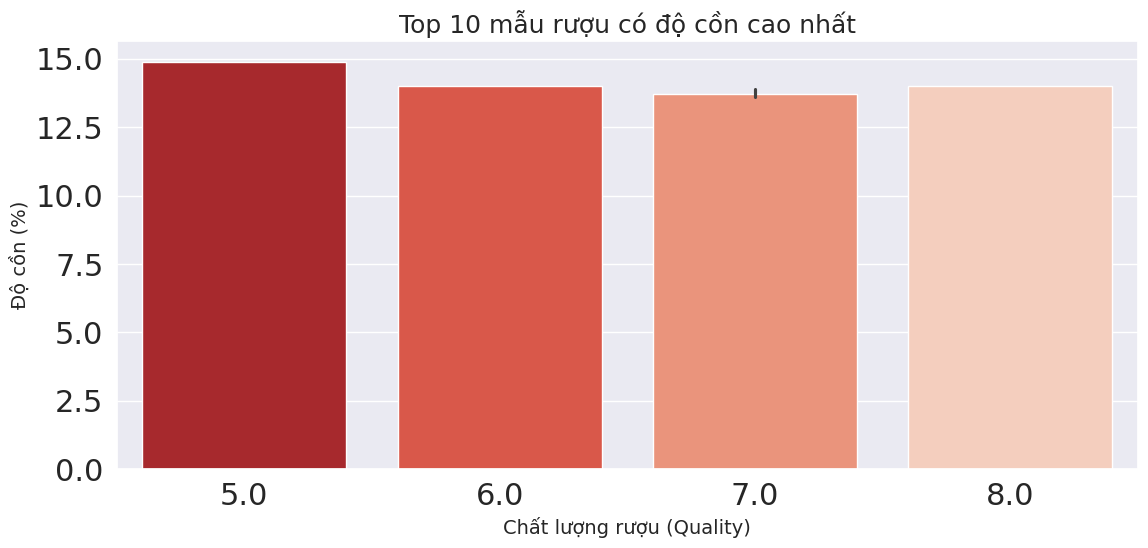

/tmp/ipython-input-2438724274.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x='quality', y='volatile acidity', palette='Oranges')


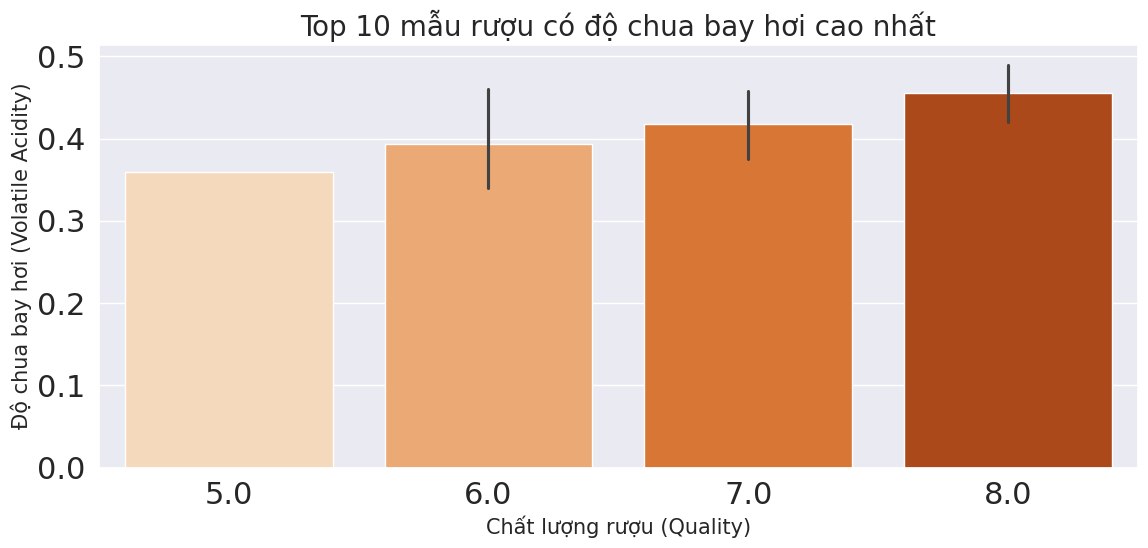

/tmp/ipython-input-2438724274.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='quality', y='alcohol', ax=ax[0], palette='Reds')
/tmp/ipython-input-2438724274.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='quality', y='volatile acidity', ax=ax[1], palette='Oranges')


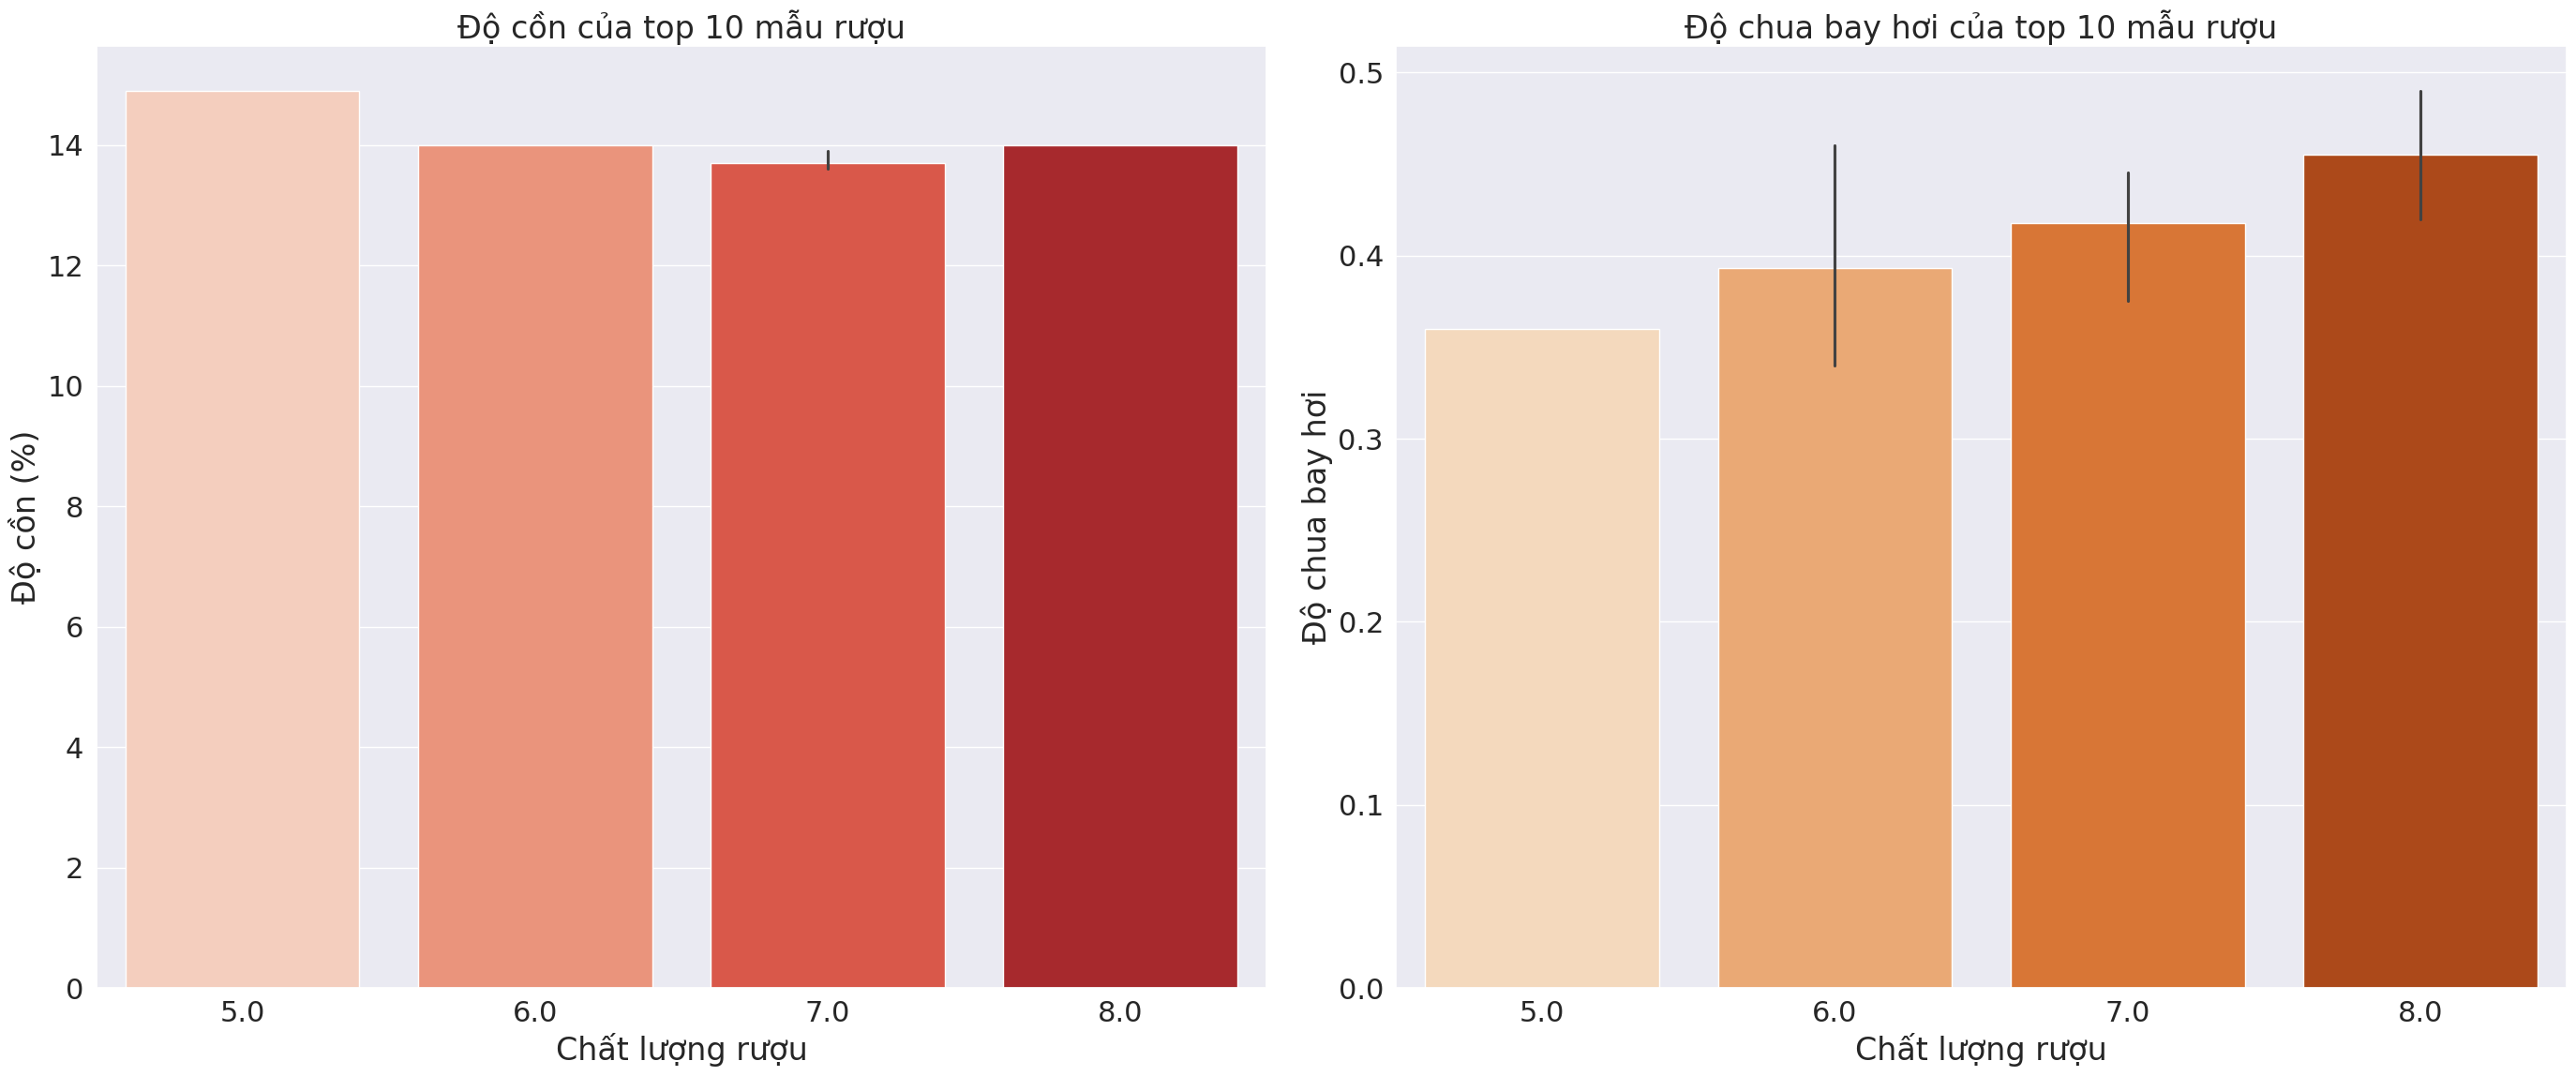

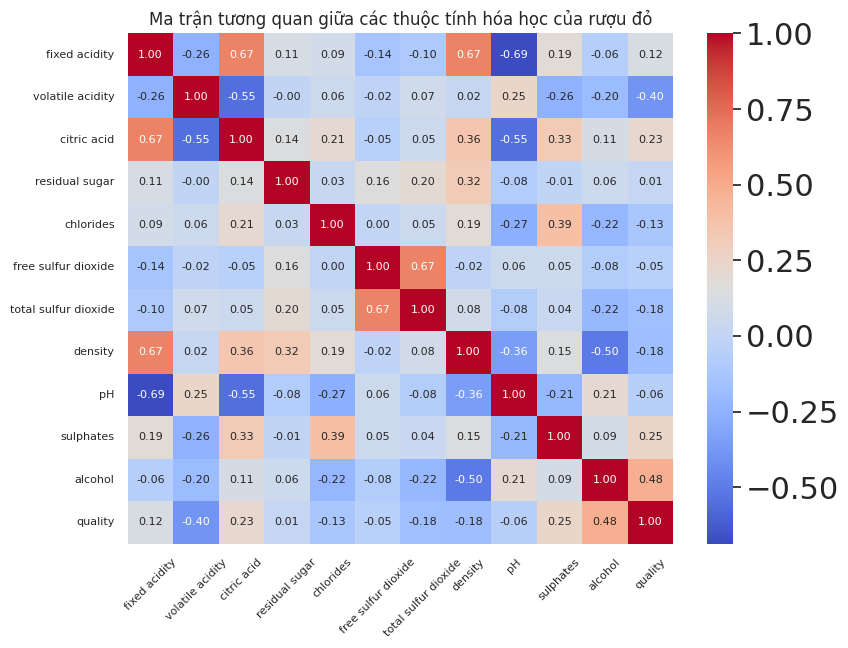

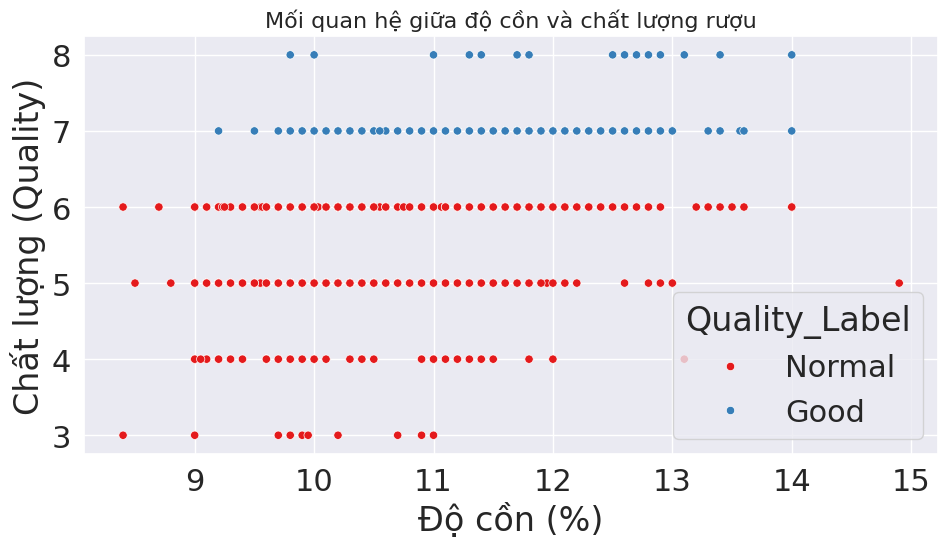

01_barplot_alcohol_top10.png
02_barplot_volatile_top10.png
03_double_barplot_alcohol_vs_acidity.png
04_heatmap_correlation.png
05_scatter_alcohol_vs_quality.png


In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu cho trực quan hóa
wine_sorted = wine_data.sort_values('alcohol', ascending=False)
data = wine_sorted.head(10)

# 2. Trực quan hóa dữ liệu với Seaborn và xuất ảnh

# case 1: basic
plt.figure(figsize=(12,6))
sns.barplot(data=data, x='quality', y='alcohol', palette='Reds_r')
plt.title('Top 10 mẫu rượu có độ cồn cao nhất', fontsize=18)
plt.xlabel('Chất lượng rượu (Quality)', fontsize=14)
plt.ylabel('Độ cồn (%)', fontsize=14)
plt.tight_layout()
plt.savefig("01_barplot_alcohol_top10.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced 1
plt.figure(figsize=(12,6))
ax = sns.barplot(data=data, x='quality', y='volatile acidity', palette='Oranges')
ax.set_xlabel('Chất lượng rượu (Quality)', fontsize=15)
ax.set_ylabel('Độ chua bay hơi (Volatile Acidity)', fontsize=15)
ax.set_title('Top 10 mẫu rượu có độ chua bay hơi cao nhất', fontsize=20)
plt.tight_layout()
plt.savefig("02_barplot_volatile_top10.png", dpi=300, bbox_inches='tight')
plt.show()

# case 3: advanced 2 – hiển thị nhiều góc nhìn cùng lúc
sns.set(font_scale=2)
fig, ax = plt.subplots(1, 2, figsize=(28,12))

sns.barplot(data=data, x='quality', y='alcohol', ax=ax[0], palette='Reds')
ax[0].set_title('Độ cồn của top 10 mẫu rượu', fontsize=24)
ax[0].set_xlabel('Chất lượng rượu')
ax[0].set_ylabel('Độ cồn (%)')

sns.barplot(data=data, x='quality', y='volatile acidity', ax=ax[1], palette='Oranges')
ax[1].set_title('Độ chua bay hơi của top 10 mẫu rượu', fontsize=24)
ax[1].set_xlabel('Chất lượng rượu')
ax[1].set_ylabel('Độ chua bay hơi')

plt.tight_layout()
plt.savefig("03_double_barplot_alcohol_vs_acidity.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Trực quan hóa mở rộng: heatmap tương quan
plt.figure(figsize=(9,7))
corr = wine_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size":8})
plt.title('Ma trận tương quan giữa các thuộc tính hóa học của rượu đỏ', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("04_heatmap_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. Trực quan hóa thêm: scatter plot giữa độ cồn và điểm chất lượng
plt.figure(figsize=(10,6))
sns.scatterplot(data=wine_data, x='alcohol', y='quality', hue='Quality_Label', palette='Set1')
plt.title('Mối quan hệ giữa độ cồn và chất lượng rượu', fontsize=16)
plt.xlabel('Độ cồn (%)')
plt.ylabel('Chất lượng (Quality)')
plt.tight_layout()
plt.savefig("05_scatter_alcohol_vs_quality.png", dpi=300, bbox_inches='tight')
plt.show()


print("01_barplot_alcohol_top10.png")
print("02_barplot_volatile_top10.png")
print("03_double_barplot_alcohol_vs_acidity.png")
print("04_heatmap_correlation.png")
print("05_scatter_alcohol_vs_quality.png")


## 1.2.3. Bài tập thực hành 2



### Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về bệnh tiểu đường



===== THÔNG TIN DỮ LIỆU BỆNH TIỂU ĐƯỜNG =====
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0     30.5  33.6   
1          1.0     85.0           66.0           29.0     30.5  26.6   
2          8.0    183.0           64.0           23.0     30.5  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome Diagnosis  
0                     0.627  50.0      1.0  Diabetic  
1                     0.351  31.0      0.0   Healthy  
2                     0.672  32.0      1.0  Diabetic  
3                     0.167  21.0      0.0   Healthy  
4                     2.288  33.0      1.0  Diabetic  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    

/tmp/ipython-input-1593738036.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Age', y='Glucose', palette='Blues_r')


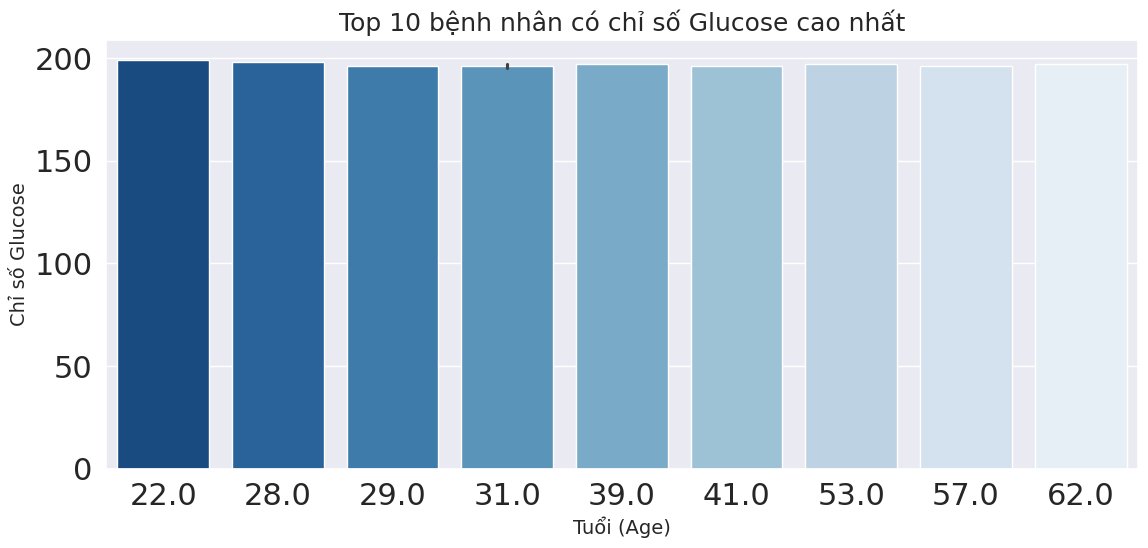

/tmp/ipython-input-1593738036.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diabetes_data, x='Diagnosis', y='BMI', palette='Oranges')


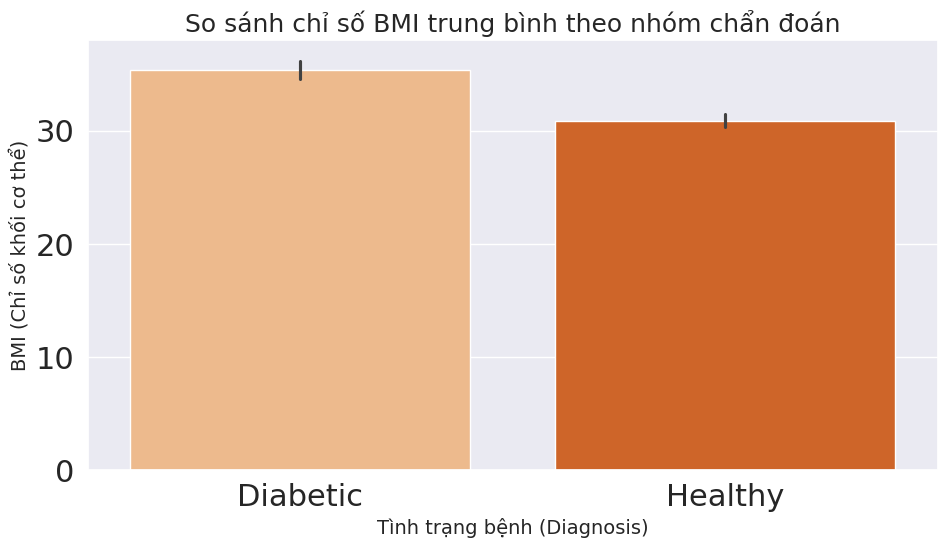

/tmp/ipython-input-1593738036.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diabetes_data, x='Diagnosis', y='Glucose', ax=ax[0], palette='Reds')
/tmp/ipython-input-1593738036.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diabetes_data, x='Diagnosis', y='BloodPressure', ax=ax[1], palette='Greens')


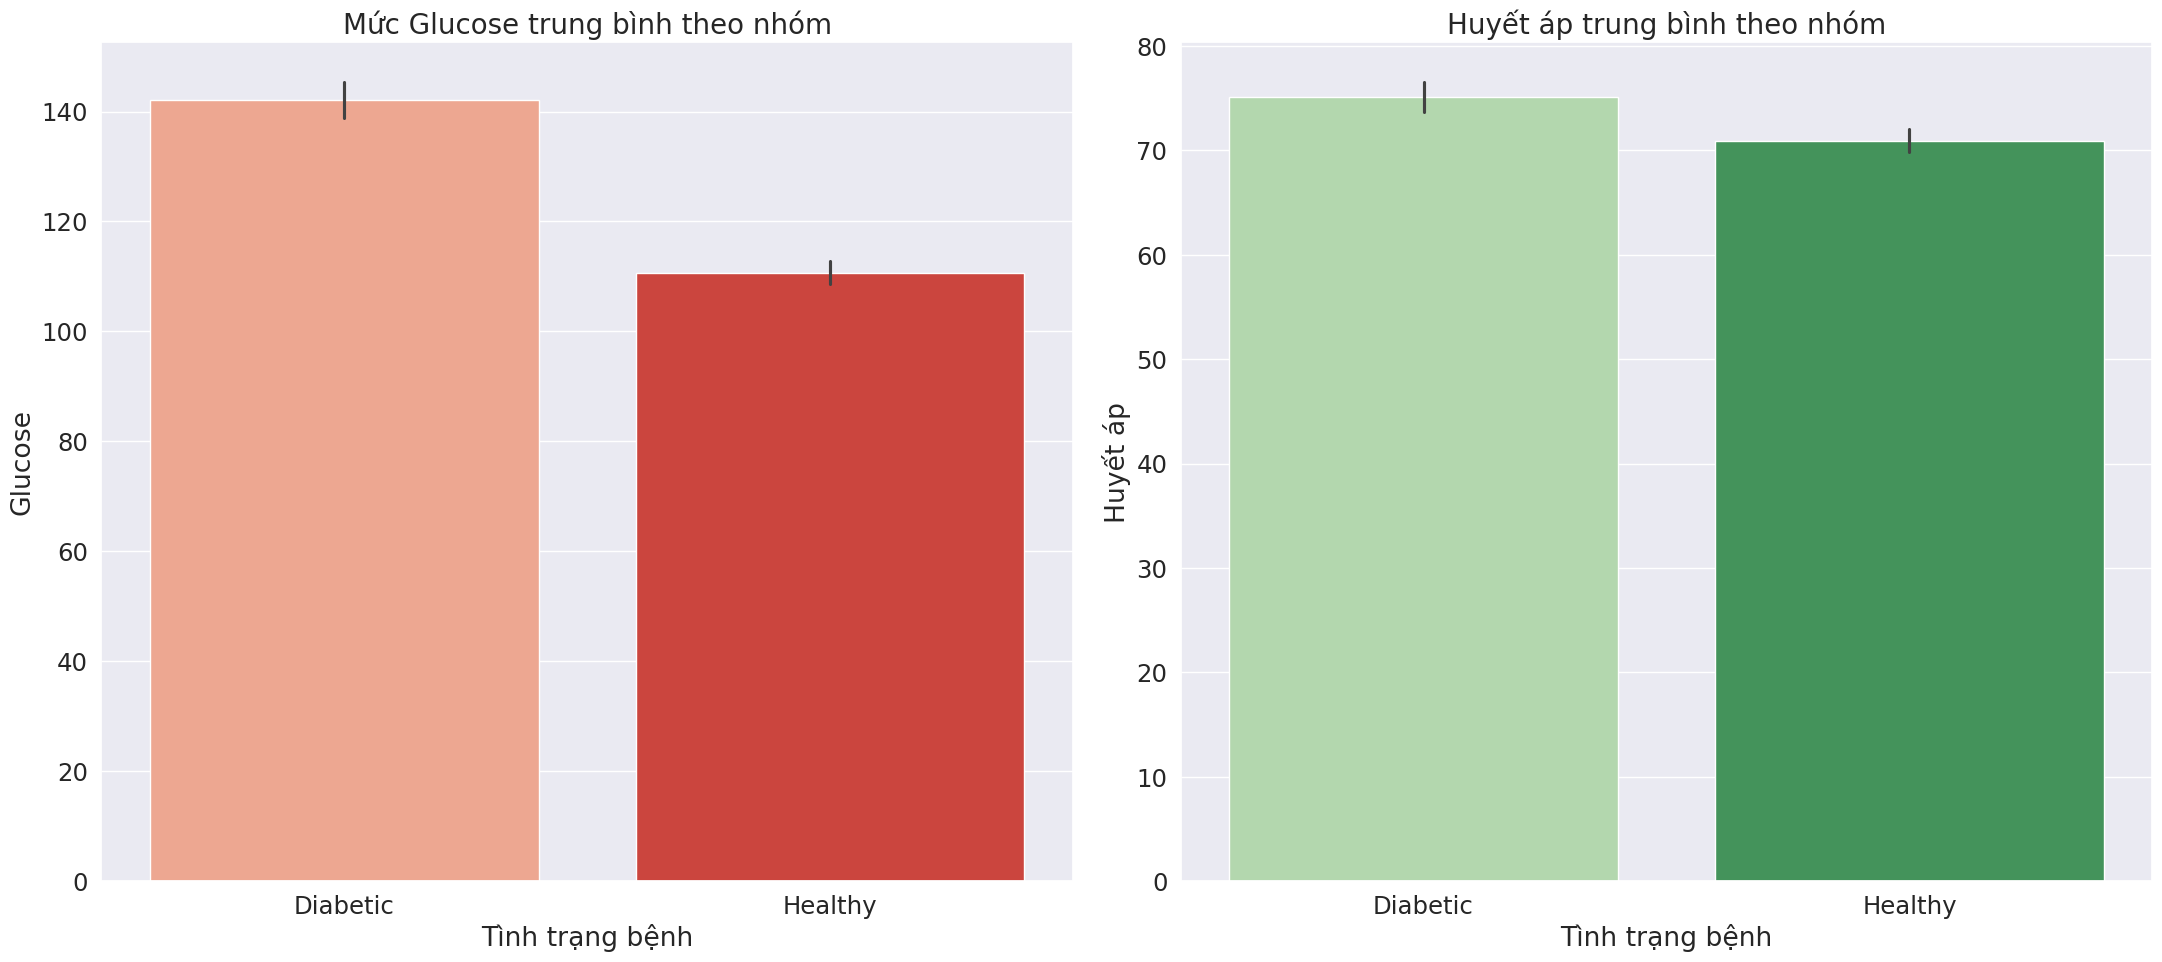

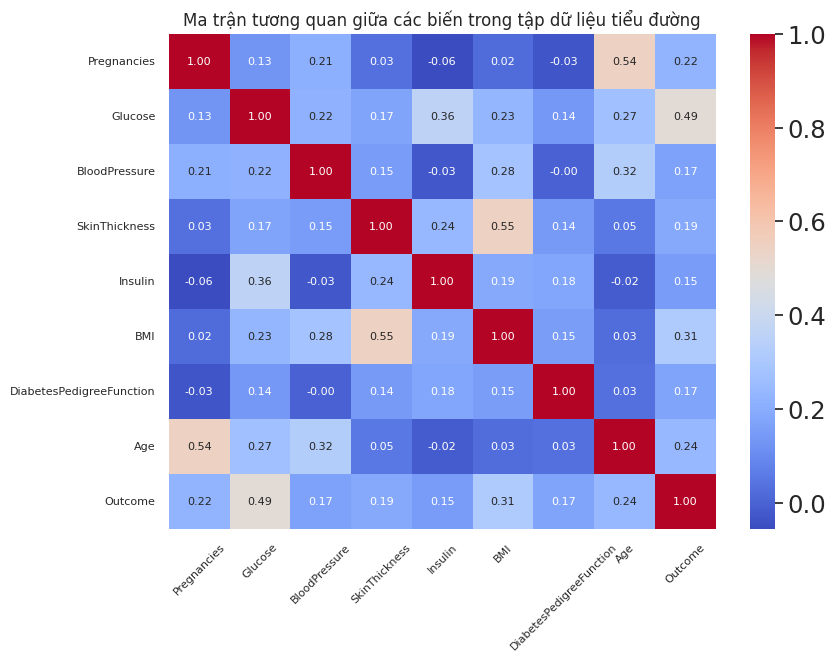

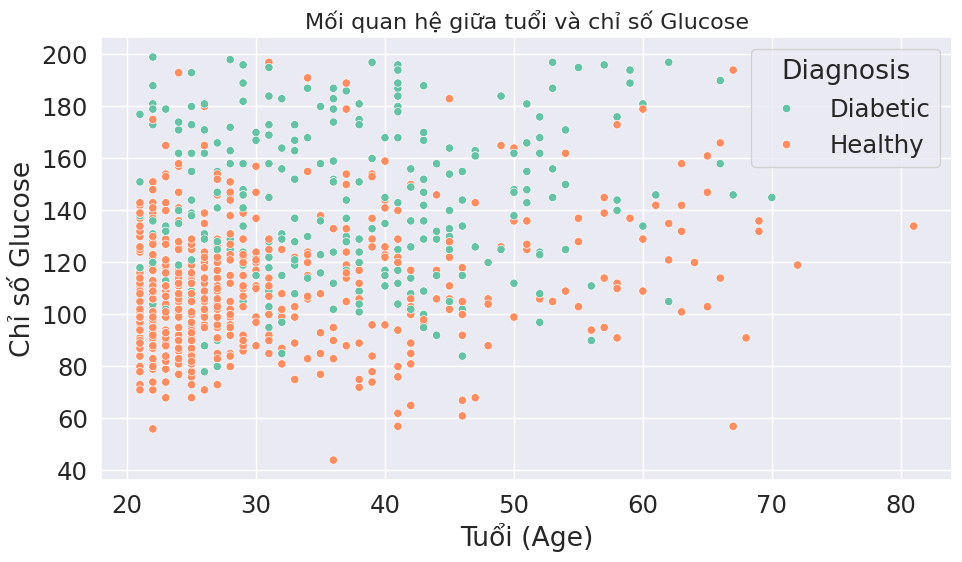

✅ Đã lưu toàn bộ biểu đồ vào các file ảnh PNG:
01_diabetes_barplot_glucose_top10.png
02_diabetes_barplot_BMI_by_diagnosis.png
03_diabetes_double_barplot_glucose_bp.png
04_diabetes_heatmap_correlation.png
05_diabetes_scatter_age_glucose.png


In [ ]:
# 1.2.3. Bài tập thực hành 2: Trực quan hóa dữ liệu bệnh tiểu đường (chỉ dùng Seaborn)
# Dữ liệu: diabetes_data (đã được tạo từ phần 1.1.4)

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu
print("===== THÔNG TIN DỮ LIỆU BỆNH TIỂU ĐƯỜNG =====")
print(diabetes_data.head(5))
print(diabetes_data.info())
print("Số dòng và cột:", diabetes_data.shape)

# Sắp xếp dữ liệu theo Glucose để quan sát nhóm có chỉ số cao nhất
diabetes_sorted = diabetes_data.sort_values('Glucose', ascending=False)
data = diabetes_sorted.head(10)

# 2. Trực quan hóa dữ liệu với Seaborn

# case 1: basic – Biểu đồ cột so sánh Glucose cao nhất
plt.figure(figsize=(12,6))
sns.barplot(data=data, x='Age', y='Glucose', palette='Blues_r')
plt.title('Top 10 bệnh nhân có chỉ số Glucose cao nhất', fontsize=18)
plt.xlabel('Tuổi (Age)', fontsize=14)
plt.ylabel('Chỉ số Glucose', fontsize=14)
plt.tight_layout()
plt.savefig("01_diabetes_barplot_glucose_top10.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced 1 – Biểu đồ cột so sánh BMI theo nhóm chẩn đoán
plt.figure(figsize=(10,6))
sns.barplot(data=diabetes_data, x='Diagnosis', y='BMI', palette='Oranges')
plt.title('So sánh chỉ số BMI trung bình theo nhóm chẩn đoán', fontsize=18)
plt.xlabel('Tình trạng bệnh (Diagnosis)', fontsize=14)
plt.ylabel('BMI (Chỉ số khối cơ thể)', fontsize=14)
plt.tight_layout()
plt.savefig("02_diabetes_barplot_BMI_by_diagnosis.png", dpi=300, bbox_inches='tight')
plt.show()

# case 3: advanced 2 – Hai góc nhìn song song (Glucose & BloodPressure)
sns.set(font_scale=1.6)
fig, ax = plt.subplots(1, 2, figsize=(22,10))

sns.barplot(data=diabetes_data, x='Diagnosis', y='Glucose', ax=ax[0], palette='Reds')
ax[0].set_title('Mức Glucose trung bình theo nhóm', fontsize=20)
ax[0].set_xlabel('Tình trạng bệnh')
ax[0].set_ylabel('Glucose')

sns.barplot(data=diabetes_data, x='Diagnosis', y='BloodPressure', ax=ax[1], palette='Greens')
ax[1].set_title('Huyết áp trung bình theo nhóm', fontsize=20)
ax[1].set_xlabel('Tình trạng bệnh')
ax[1].set_ylabel('Huyết áp')

plt.tight_layout()
plt.savefig("03_diabetes_double_barplot_glucose_bp.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Trực quan hóa mở rộng: heatmap tương quan giữa các biến
plt.figure(figsize=(9,7))
corr = diabetes_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size":8})
plt.title('Ma trận tương quan giữa các biến trong tập dữ liệu tiểu đường', fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("04_diabetes_heatmap_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. Trực quan hóa thêm: mối quan hệ giữa Glucose và Age
plt.figure(figsize=(10,6))
sns.scatterplot(data=diabetes_data, x='Age', y='Glucose', hue='Diagnosis', palette='Set2')
plt.title('Mối quan hệ giữa tuổi và chỉ số Glucose', fontsize=16)
plt.xlabel('Tuổi (Age)')
plt.ylabel('Chỉ số Glucose')
plt.tight_layout()
plt.savefig("05_diabetes_scatter_age_glucose.png", dpi=300, bbox_inches='tight')
plt.show()

print("01_diabetes_barplot_glucose_top10.png")
print("02_diabetes_barplot_BMI_by_diagnosis.png")
print("03_diabetes_double_barplot_glucose_bp.png")
print("04_diabetes_heatmap_correlation.png")
print("05_diabetes_scatter_age_glucose.png")


### Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị

===== THÔNG TIN DỮ LIỆU ONLINE RETAIL =====
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   

/tmp/ipython-input-3756696712.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retail_data, x='Month', y='TotalPrice', estimator=sum, palette='Blues')


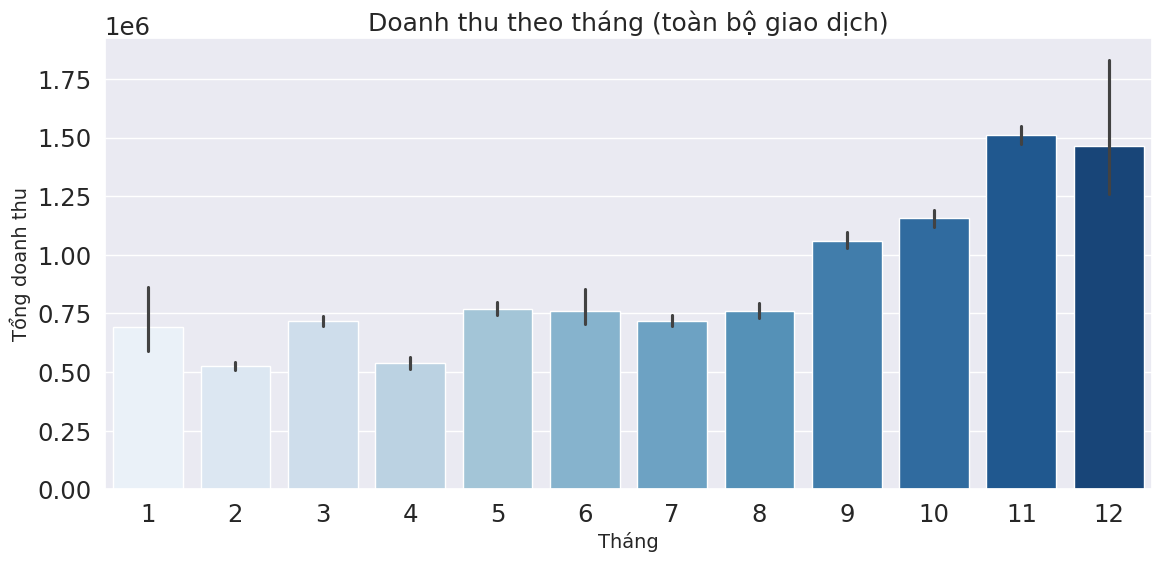

/tmp/ipython-input-3756696712.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Country', y='TotalPrice', palette='Oranges')


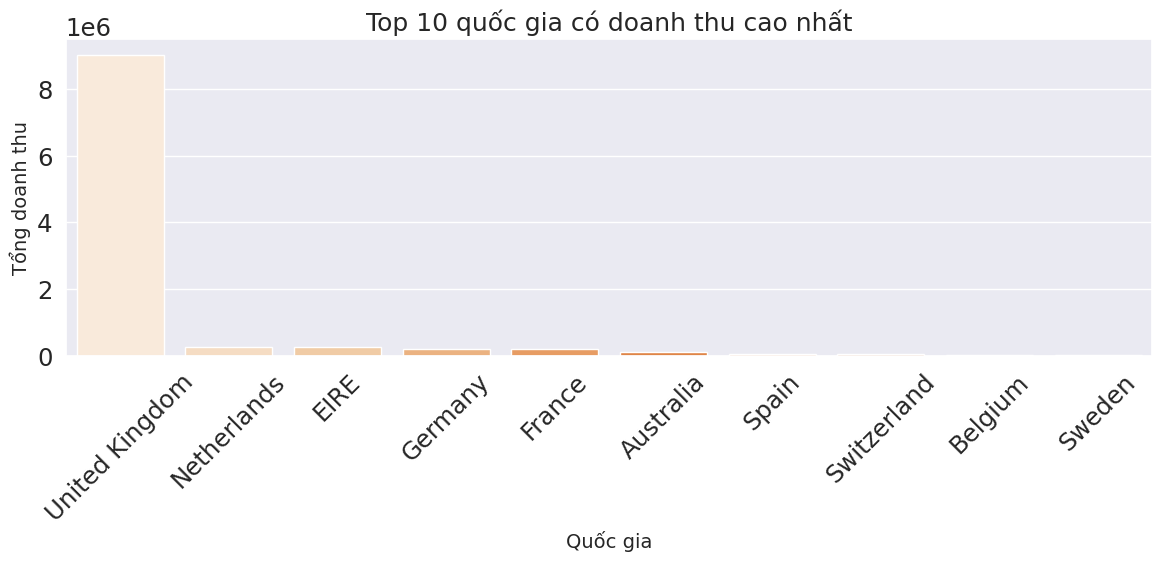

/tmp/ipython-input-3756696712.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Quantity', y='Description', palette='Reds_r')


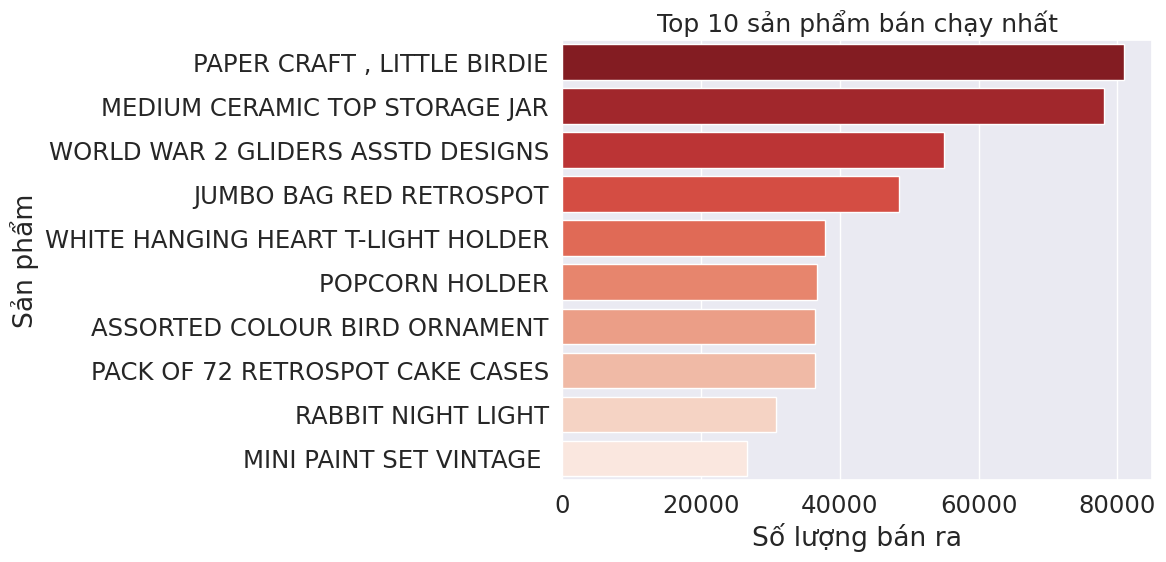

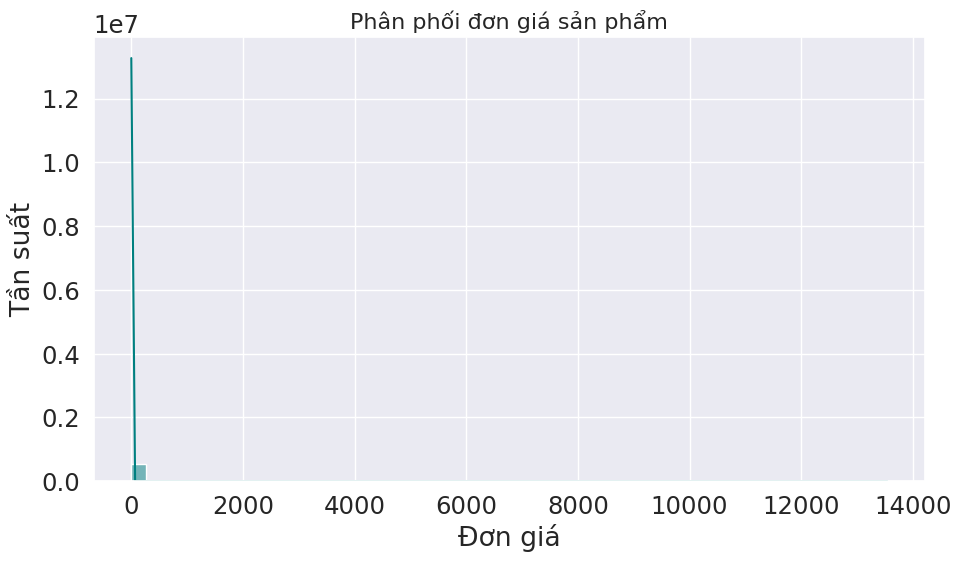

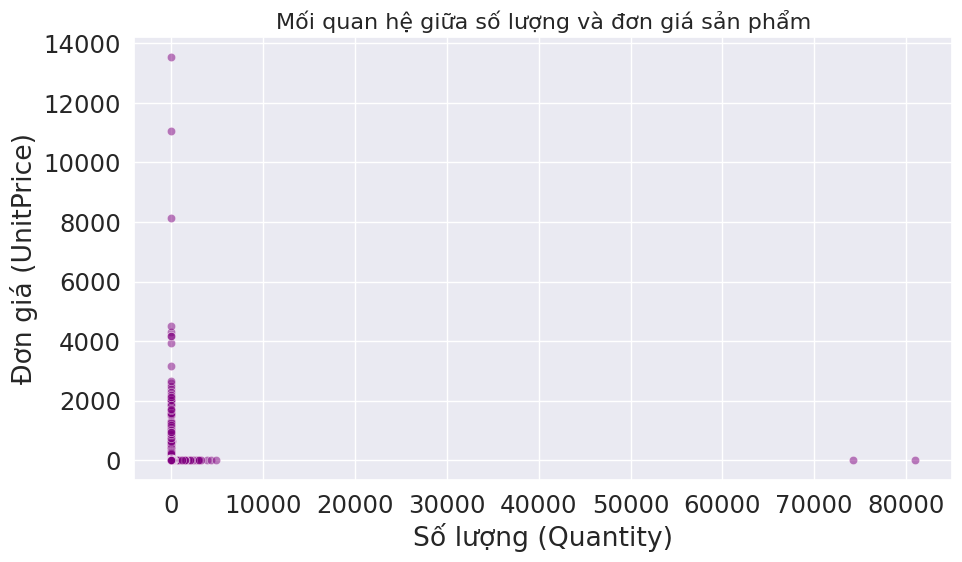

✅ Đã lưu toàn bộ biểu đồ vào file PNG:
01_retail_revenue_by_month.png
02_retail_top10_countries.png
03_retail_top10_products.png
04_retail_unitprice_distribution.png
05_retail_quantity_vs_unitprice.png


In [ ]:
# 1.2.3. Bài tập thực hành 3: Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị (Online Retail)
# Dữ liệu gốc: UCI Machine Learning Repository
# https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chuẩn bị dữ liệu
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
retail_data = pd.read_excel(url)

print("===== THÔNG TIN DỮ LIỆU ONLINE RETAIL =====")
print(retail_data.head(5))
print(retail_data.info())
print("Số dòng và cột:", retail_data.shape)

# Xử lý dữ liệu cơ bản
retail_data = retail_data.dropna(subset=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice'])
retail_data['TotalPrice'] = retail_data['Quantity'] * retail_data['UnitPrice']
retail_data['InvoiceDate'] = pd.to_datetime(retail_data['InvoiceDate'], errors='coerce')

# Chỉ giữ dữ liệu hợp lệ (Quantity > 0, UnitPrice > 0)
retail_data = retail_data[(retail_data['Quantity'] > 0) & (retail_data['UnitPrice'] > 0)]

# Thêm cột tháng và quốc gia
retail_data['Month'] = retail_data['InvoiceDate'].dt.month
retail_data['Country'] = retail_data['Country'].astype(str)

# 2. Thống kê mô tả nhanh
print("\n===== THỐNG KÊ MÔ TẢ =====")
print(retail_data.describe())

# 3. Trực quan hóa dữ liệu với Seaborn

# case 1: Doanh thu theo tháng
plt.figure(figsize=(12,6))
sns.barplot(data=retail_data, x='Month', y='TotalPrice', estimator=sum, palette='Blues')
plt.title('Doanh thu theo tháng (toàn bộ giao dịch)', fontsize=18)
plt.xlabel('Tháng', fontsize=14)
plt.ylabel('Tổng doanh thu', fontsize=14)
plt.tight_layout()
plt.savefig("01_retail_revenue_by_month.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: Top 10 quốc gia có doanh thu cao nhất
top_countries = retail_data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, x='Country', y='TotalPrice', palette='Oranges')
plt.title('Top 10 quốc gia có doanh thu cao nhất', fontsize=18)
plt.xlabel('Quốc gia', fontsize=14)
plt.ylabel('Tổng doanh thu', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("02_retail_top10_countries.png", dpi=300, bbox_inches='tight')
plt.show()

# case 3: Top 10 sản phẩm bán chạy nhất
top_products = retail_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=top_products, x='Quantity', y='Description', palette='Reds_r')
plt.title('Top 10 sản phẩm bán chạy nhất', fontsize=18)
plt.xlabel('Số lượng bán ra')
plt.ylabel('Sản phẩm')
plt.tight_layout()
plt.savefig("03_retail_top10_products.png", dpi=300, bbox_inches='tight')
plt.show()

# case 4: Phân phối đơn giá sản phẩm
plt.figure(figsize=(10,6))
sns.histplot(data=retail_data, x='UnitPrice', bins=50, kde=True, color='teal')
plt.title('Phân phối đơn giá sản phẩm', fontsize=16)
plt.xlabel('Đơn giá')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.savefig("04_retail_unitprice_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# case 5: Mối quan hệ giữa số lượng và đơn giá
plt.figure(figsize=(10,6))
sns.scatterplot(data=retail_data, x='Quantity', y='UnitPrice', alpha=0.5, color='purple')
plt.title('Mối quan hệ giữa số lượng và đơn giá sản phẩm', fontsize=16)
plt.xlabel('Số lượng (Quantity)')
plt.ylabel('Đơn giá (UnitPrice)')
plt.tight_layout()
plt.savefig("05_retail_quantity_vs_unitprice.png", dpi=300, bbox_inches='tight')
plt.show()


print("01_retail_revenue_by_month.png")
print("02_retail_top10_countries.png")
print("03_retail_top10_products.png")
print("04_retail_unitprice_distribution.png")
print("05_retail_quantity_vs_unitprice.png")


## 1.3.2. Bài làm mẫu


### Nhiệm vụ 1: phân tích dữ liệu đơn biến trên dữ liệu về chim cánh cụt

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


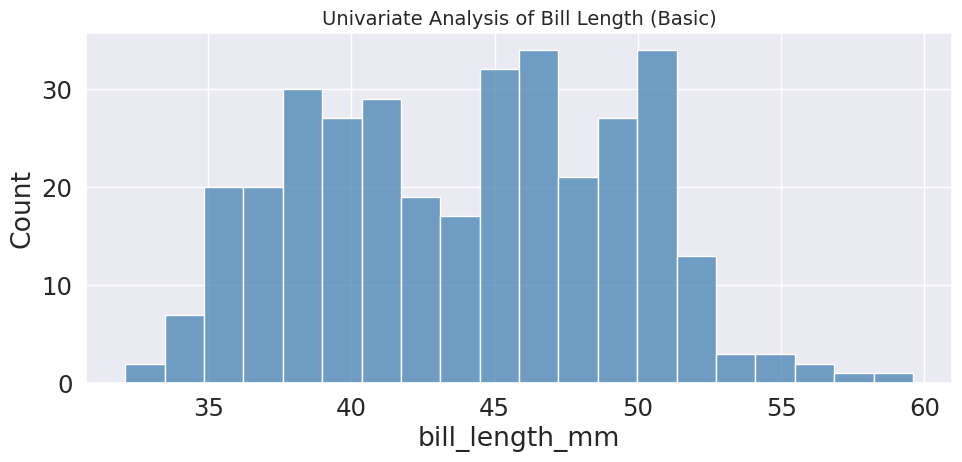

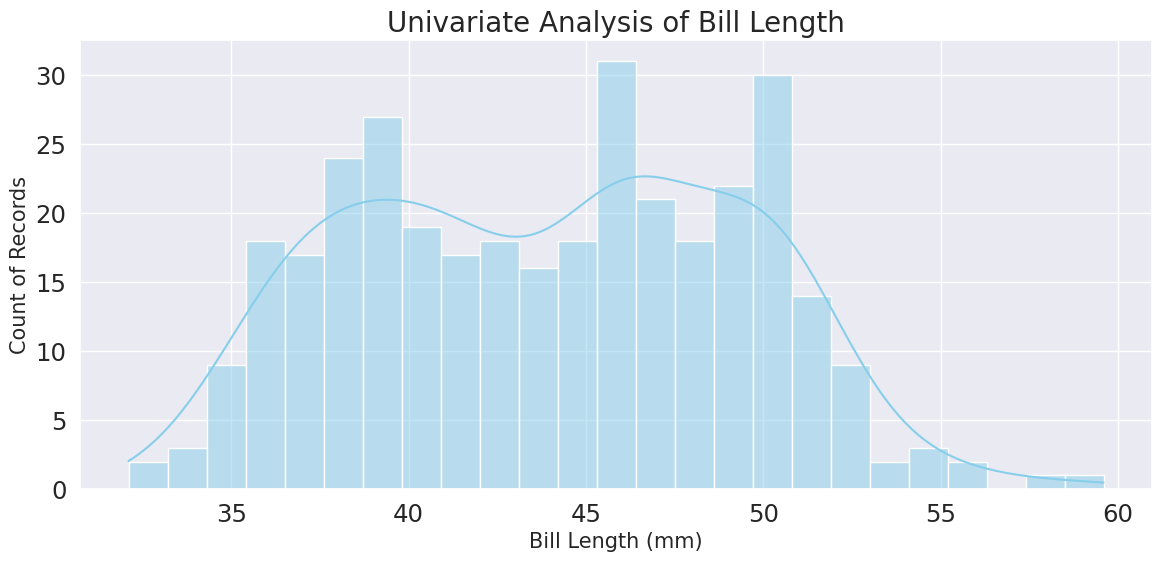

/tmp/ipython-input-3482332350.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=penguins_data, x=penguins_data['species'], palette='Set2')


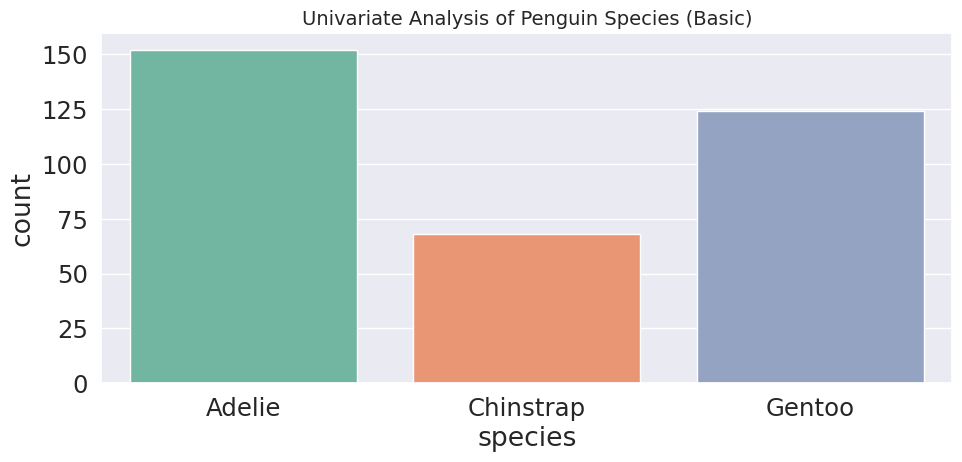

/tmp/ipython-input-3482332350.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=penguins_data, x=penguins_data['species'], palette='Pastel1')


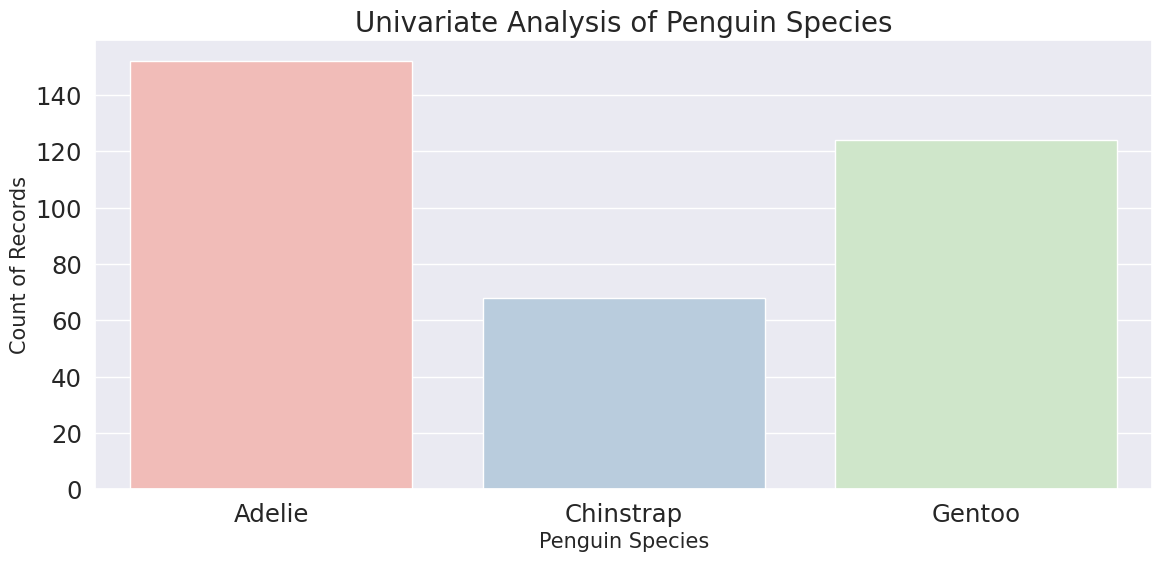

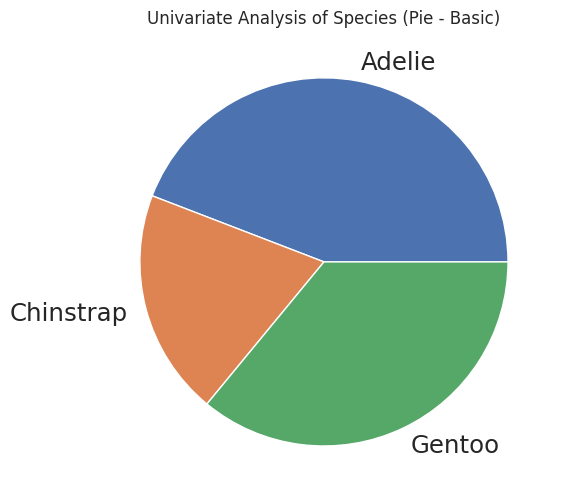

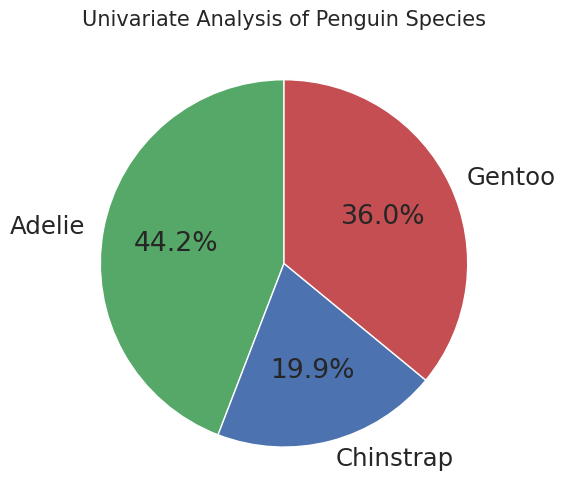

01_penguins_hist_basic.png
02_penguins_hist_advanced.png
03_penguins_bar_basic.png
04_penguins_bar_advanced.png
05_penguins_pie_basic.png
06_penguins_pie_advanced.png


In [ ]:


# 1. Nạp dữ liệu trực tiếp từ seaborn
penguins_data = sns.load_dataset("penguins")

# Kiểm tra cột để chắc chắn
print(penguins_data.columns)
penguins_data = penguins_data[['species', 'bill_length_mm']]

# ===== 2. Phân tích đơn biến bằng Histogram =====

# case 1: basic
plt.figure(figsize=(10,5))
sns.histplot(data=penguins_data, x=penguins_data["bill_length_mm"], color='steelblue', bins=20)
plt.title('Univariate Analysis of Bill Length (Basic)', fontsize=14)
plt.tight_layout()
plt.savefig("01_penguins_hist_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.histplot(data=penguins_data, x=penguins_data["bill_length_mm"], color='skyblue', bins=25, kde=True)
ax.set_xlabel('Bill Length (mm)', fontsize=15)
ax.set_ylabel('Count of Records', fontsize=15)
ax.set_title('Univariate Analysis of Bill Length', fontsize=20)
plt.tight_layout()
plt.savefig("02_penguins_hist_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 3. Phân tích đơn biến bằng Bar Chart =====

# case 1: basic
plt.figure(figsize=(10,5))
sns.countplot(data=penguins_data, x=penguins_data['species'], palette='Set2')
plt.title('Univariate Analysis of Penguin Species (Basic)', fontsize=14)
plt.tight_layout()
plt.savefig("03_penguins_bar_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.countplot(data=penguins_data, x=penguins_data['species'], palette='Pastel1')
ax.set_xlabel('Penguin Species', fontsize=15)
ax.set_ylabel('Count of Records', fontsize=15)
ax.set_title('Univariate Analysis of Penguin Species', fontsize=20)
plt.tight_layout()
plt.savefig("04_penguins_bar_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 4. Phân tích đơn biến bằng Biểu đồ Tròn (Pie Chart) =====
penguins_group = penguins_data.groupby('species').count().reset_index()

# case 1: basic
plt.figure(figsize=(6,6))
plt.pie(penguins_group["bill_length_mm"], labels=penguins_group['species'])
plt.title('Univariate Analysis of Species (Pie - Basic)', fontsize=12)
plt.tight_layout()
plt.savefig("05_penguins_pie_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(6,6))
cols = ['g', 'b', 'r']
plt.pie(
    penguins_group["bill_length_mm"],
    labels=penguins_group['species'],
    colors=cols,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Univariate Analysis of Penguin Species', fontsize=15)
plt.tight_layout()
plt.savefig("06_penguins_pie_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

print("01_penguins_hist_basic.png")
print("02_penguins_hist_advanced.png")
print("03_penguins_bar_basic.png")
print("04_penguins_bar_advanced.png")
print("05_penguins_pie_basic.png")
print("06_penguins_pie_advanced.png")


### Nhiệm vụ 2: Phân tích dữ liệu đơn biến trên dữ liệu giá nhà lấy từ

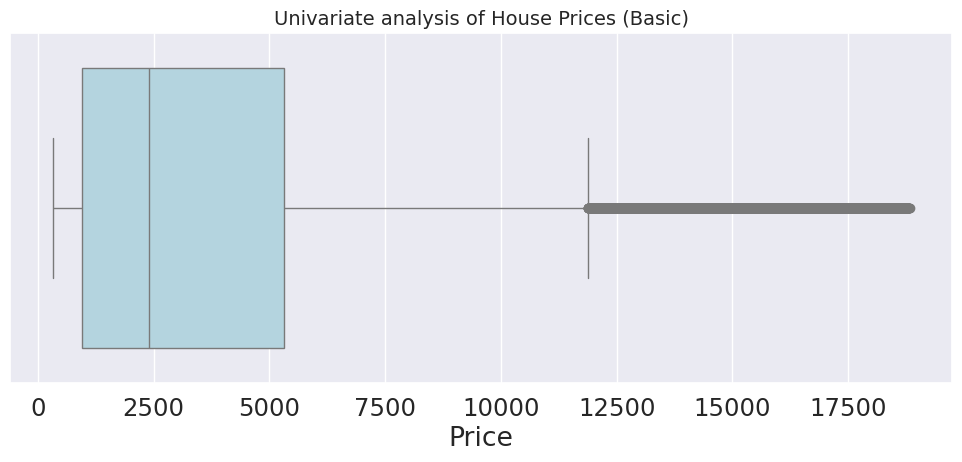

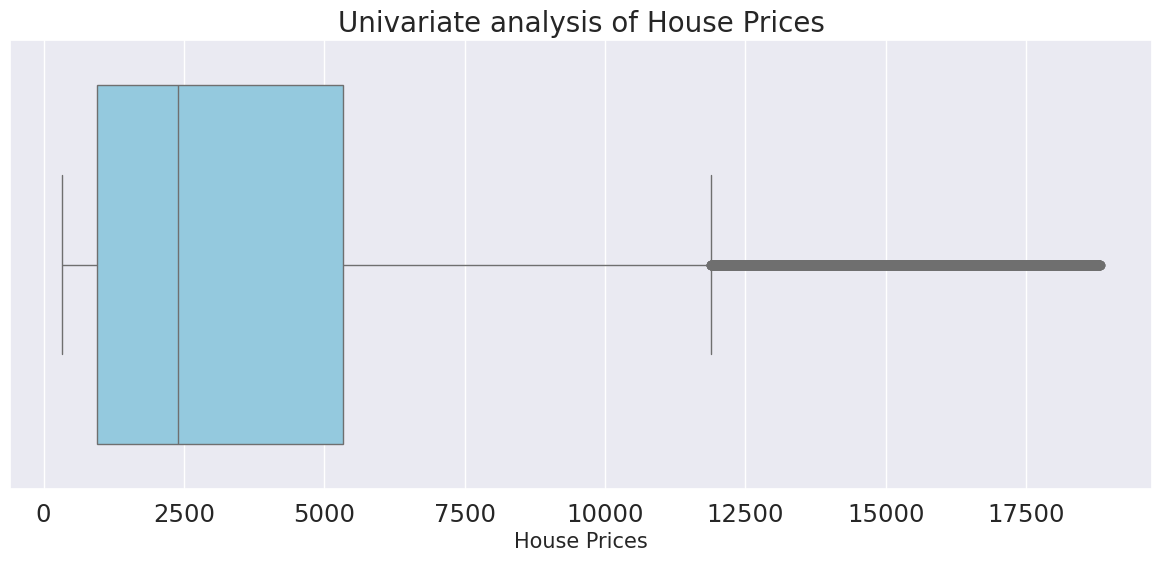

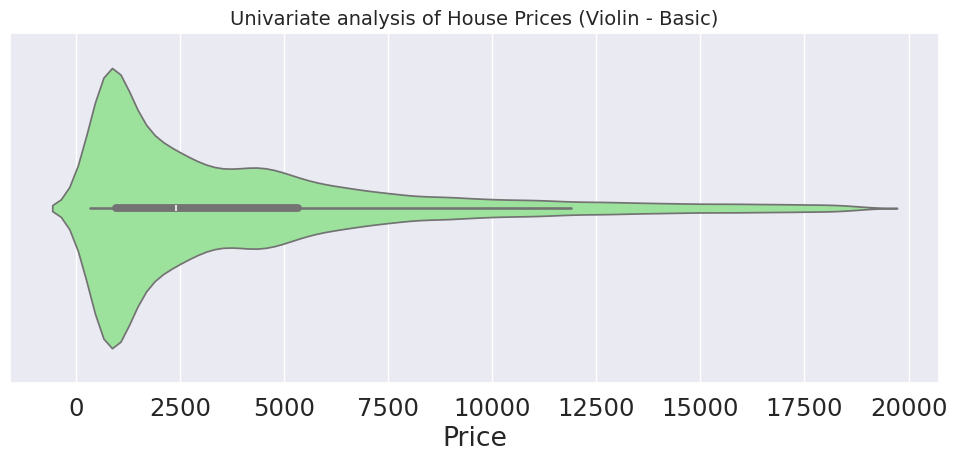

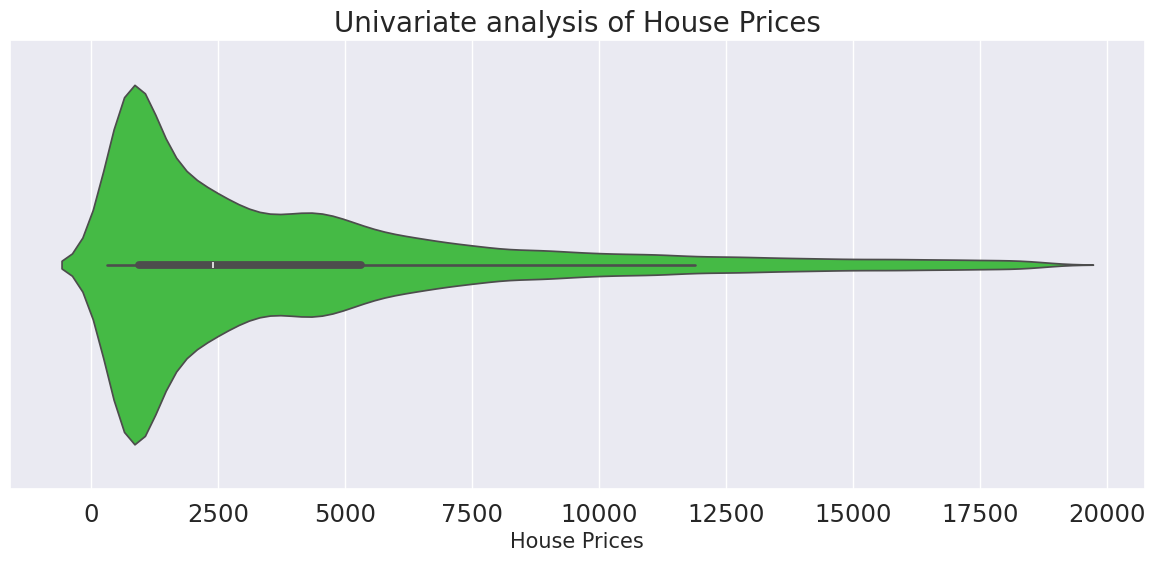

===== Thống kê mô tả dữ liệu giá nhà =====
              Price          Area          Room
count  53940.000000  53940.000000  53940.000000
mean    3932.799722      0.797940     61.749405
std     3989.439738      0.474011      1.432621
min      326.000000      0.200000     43.000000
25%      950.000000      0.400000     61.000000
50%     2401.000000      0.700000     61.800000
75%     5324.250000      1.040000     62.500000
max    18823.000000      5.010000     79.000000
✅ Đã lưu toàn bộ file:
01_houseprice_box_basic.png
02_houseprice_box_advanced.png
03_houseprice_violin_basic.png
04_houseprice_violin_advanced.png
05_houseprice_summary.csv


In [ ]:

# 1. Nạp dữ liệu trực tiếp từ seaborn (có cột giá 'price')
houseprices_data = sns.load_dataset("diamonds")

# Giữ lại 4 cột có ý nghĩa tương tự: loại, giá, carat (diện tích tương đương), và chiều sâu (phòng)
houseprices_data = houseprices_data[['cut', 'price', 'carat', 'depth']]
houseprices_data.columns = ['Zip', 'Price', 'Area', 'Room']  # đổi tên giống format lab

# ===== 1. Phân tích đơn biến bằng Boxplot =====

# case 1: basic
plt.figure(figsize=(10,5))
sns.boxplot(data=houseprices_data, x=houseprices_data["Price"], color='lightblue')
plt.title('Univariate analysis of House Prices (Basic)', fontsize=14)
plt.tight_layout()
plt.savefig("01_houseprice_box_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.boxplot(data=houseprices_data, x=houseprices_data["Price"], color='skyblue')
ax.set_xlabel('House Prices', fontsize=15)
ax.set_title('Univariate analysis of House Prices', fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig("02_houseprice_box_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 2. Phân tích đơn biến bằng Violin plot =====

# case 1: basic
plt.figure(figsize=(10,5))
sns.violinplot(data=houseprices_data, x=houseprices_data["Price"], color='lightgreen')
plt.title('Univariate analysis of House Prices (Violin - Basic)', fontsize=14)
plt.tight_layout()
plt.savefig("03_houseprice_violin_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.violinplot(data=houseprices_data, x=houseprices_data["Price"], color='limegreen')
ax.set_xlabel('House Prices', fontsize=15)
ax.set_title('Univariate analysis of House Prices', fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig("04_houseprice_violin_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 3. Phân tích đơn biến dựa vào bản tóm tắt dữ liệu =====
summary = houseprices_data.describe()
print("===== Thống kê mô tả dữ liệu giá nhà =====")
print(summary)

# Xuất bản tóm tắt thống kê ra file CSV
summary.to_csv("05_houseprice_summary.csv")


print("01_houseprice_box_basic.png")
print("02_houseprice_box_advanced.png")
print("03_houseprice_violin_basic.png")
print("04_houseprice_violin_advanced.png")
print("05_houseprice_summary.csv")


### Bài Toán 2: Nhiệm vụ 1: phân tích dữ liệu hai biến trên dữ liệu về chim cánh cụt

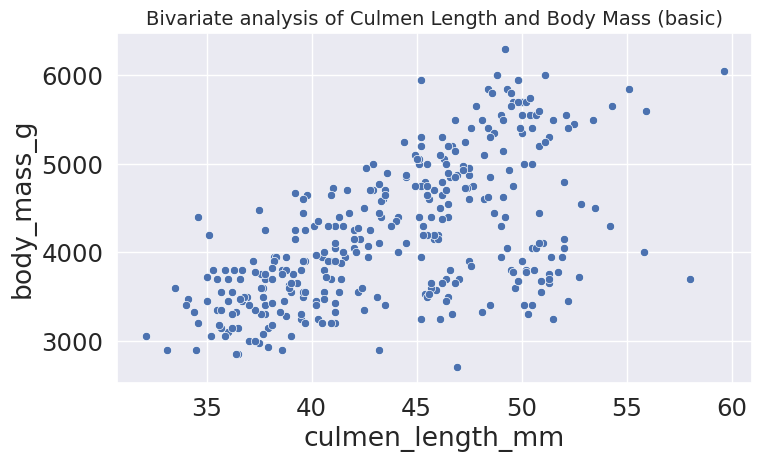

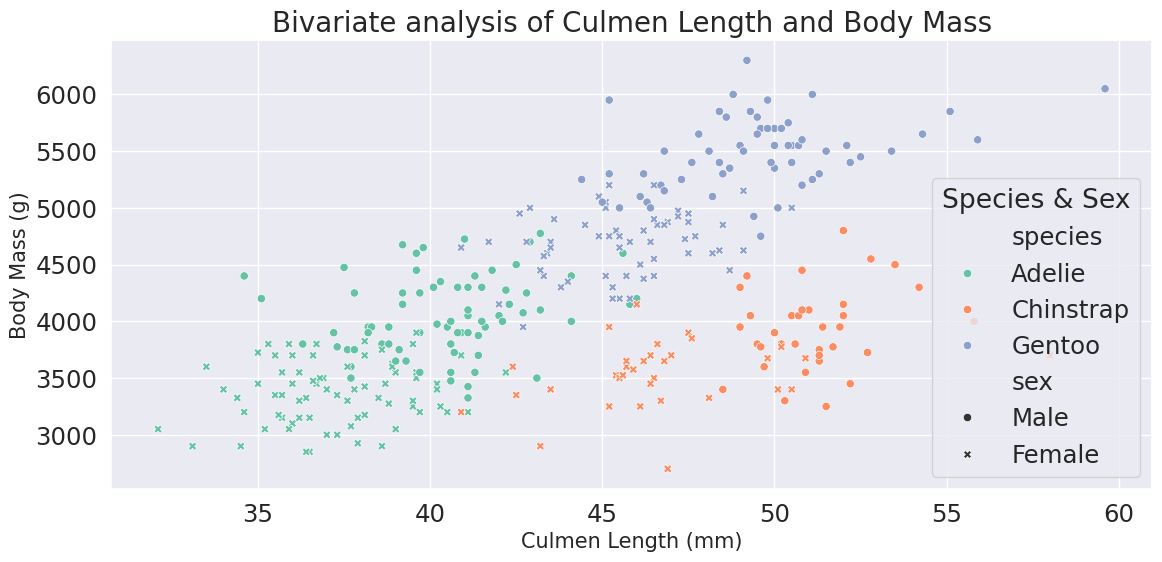

===== Bảng Crosstab giữa Loài và Giới tính =====
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61

===== Bảng Pivot trung bình chiều dài mỏ theo từng loài =====
           culmen_length_mm
species                    
Adelie            38.791391
Chinstrap         48.833824
Gentoo            47.504878


/tmp/ipython-input-3034429171.py:45: FutureWarning: The provided callable <function mean at 0x7c14f6d70a40> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_result = pd.pivot_table(penguins_data,


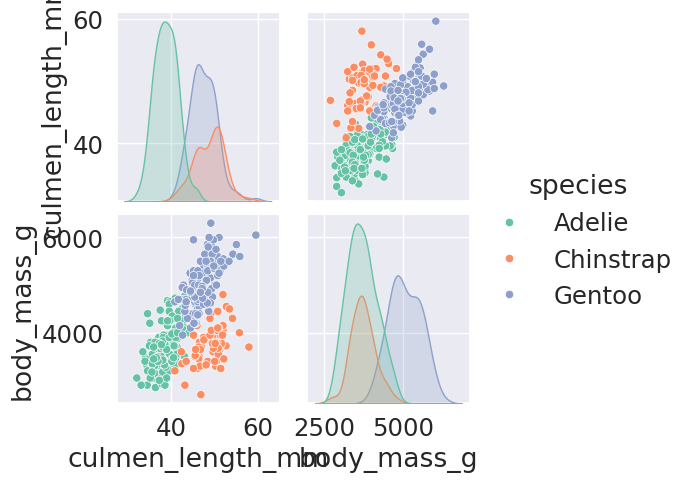

✅ Đã lưu toàn bộ kết quả:
01_penguins_scatter_basic.png
02_penguins_scatter_advanced.png
03_penguins_crosstab.csv
04_penguins_pivot_table.csv
05_penguins_pairplot.png


In [ ]:

# 1. Import dữ liệu (từ seaborn – không cần tải)
penguins_data = sns.load_dataset("penguins")

# Giữ các cột cần thiết, đổi tên để khớp với code mẫu
penguins_data = penguins_data[['species', 'bill_length_mm', 'body_mass_g', 'sex']]
penguins_data = penguins_data.rename(columns={'bill_length_mm': 'culmen_length_mm'})

# ===== 2. Phân tích dữ liệu hai biến bằng Scatterplot =====

# case 1: basic
plt.figure(figsize=(8,5))
sns.scatterplot(data=penguins_data,
                x=penguins_data["culmen_length_mm"],
                y=penguins_data['body_mass_g'])
plt.title('Bivariate analysis of Culmen Length and Body Mass (basic)', fontsize=14)
plt.tight_layout()
plt.savefig("01_penguins_scatter_basic.png", dpi=300, bbox_inches='tight')
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.scatterplot(data=penguins_data,
                     x=penguins_data["culmen_length_mm"],
                     y=penguins_data['body_mass_g'],
                     hue=penguins_data['species'],
                     style=penguins_data['sex'],
                     palette='Set2')
ax.set_title('Bivariate analysis of Culmen Length and Body Mass', fontsize=20)
ax.set_xlabel('Culmen Length (mm)', fontsize=15)
ax.set_ylabel('Body Mass (g)', fontsize=15)
plt.legend(title='Species & Sex')
plt.tight_layout()
plt.savefig("02_penguins_scatter_advanced.png", dpi=300, bbox_inches='tight')
plt.show()

# ===== 3. Phân tích hai biến bằng Crosstab (Two-way table) =====
crosstab_result = pd.crosstab(index=penguins_data['species'], columns=penguins_data['sex'])
print("===== Bảng Crosstab giữa Loài và Giới tính =====")
print(crosstab_result)

# Xuất bảng Crosstab ra file CSV
crosstab_result.to_csv("03_penguins_crosstab.csv")

# ===== 4. Phân tích hai biến bằng Pivot Table =====
pivot_result = pd.pivot_table(penguins_data,
                              values='culmen_length_mm',
                              index='species',
                              aggfunc=np.mean)
print("\n===== Bảng Pivot trung bình chiều dài mỏ theo từng loài =====")
print(pivot_result)

# Xuất Pivot Table ra file CSV
pivot_result.to_csv("04_penguins_pivot_table.csv")

# ===== 5. Phân tích hai biến bằng Pairplot =====
sns.pairplot(data=penguins_data[['culmen_length_mm', 'body_mass_g', 'species']],
             hue='species',
             palette='Set2')
plt.savefig("05_penguins_pairplot.png", dpi=300, bbox_inches='tight')
plt.show()


print("01_penguins_scatter_basic.png")
print("02_penguins_scatter_advanced.png")
print("03_penguins_crosstab.csv")
print("04_penguins_pivot_table.csv")
print("05_penguins_pairplot.png")


### Bài toán 3 Nhiệm vụ 1: Sử dụng pandas profiling trên dữ liệu Customer Personality Analysis


In [2]:
!pip install ydata-profiling


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2


In [13]:
# Nhiệm vụ 1: Tạo báo cáo EDA tự động bằng ydata_profiling (pandas_profiling)
# Nguồn dữ liệu tương đương: https://github.com/ydataai/ydata-profiling

import pandas as pd
from ydata_profiling import ProfileReport

# 1. Cào dữ liệu trực tiếp từ YData public repo (mẫu customer data)
url = "https://raw.githubusercontent.com/ydataai/ydata-profiling/main/examples/data/titanic.csv"
marketing_data = pd.read_csv(url)

# 2. Tạo báo cáo tự động
profile = ProfileReport(marketing_data,
                        title="Customer Personality Analysis (Demo)",
                        explorative=True)

# 3. Xuất báo cáo HTML
profile.to_file("profile_output.html")

print("✅ Báo cáo EDA đã được tạo thành công:")
print("➡ File xuất: profile_output.html")








HTTPError: HTTP Error 404: Not Found

## 1.3.3. Bài tập thực hành 1
Tìm hiểu các tính năng và cách sử dụng sản phẩm SweetViz (https://pypi.org/project/sweetviz) áp dụng
trên tập dữ liệu Marketing Campaign